In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import curve_fit

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.thorlabs import ThorCam

from slmsuite.hardware.cameraslms import FourierSLM

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


In [2]:
cam = ThorCam()

TLCameraSDK initializing... success
Looking for cameras... success
ThorCam sn '38459' initializing... success


In [3]:
lut_path = "interpolated_voltage.lut"

slm = Meadowlark(lut_path=lut_path, wav_um=.688, settle_time_s=.3)

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...

In [4]:
# 0.4ms
cam.set_exposure(0.0002)

0.000193

In [5]:
def make_mirror_grating(
    shape: tuple[int, int],
    left_value: int,
    bar_width: int,
    bar_values: tuple[int, int] = (0, 100),
) -> np.ndarray:
    """
    Create a uint8 image where:
      - the left half has a constant value;
      - the right half contains alternating vertical bars.

    Parameters
    ----------
    shape:
        Image size as (height, width).
    left_value:
        Value for the left half, from 0 to 255.
    bar_width:
        Width of each vertical bar in pixels.
    bar_values:
        Alternating values for the bars.

    Returns
    -------
    np.ndarray
        A 2D uint8 array with the requested pattern.
    """
    height, width = shape

    if height <= 0 or width <= 0:
        raise ValueError("Height and width must be positive.")
    if not 0 <= left_value <= 255:
        raise ValueError("left_value must be between 0 and 255.")
    if bar_width <= 0:
        raise ValueError("bar_width must be a positive integer.")
    if any(not 0 <= value <= 255 for value in bar_values):
        raise ValueError("bar_values must be between 0 and 255.")

    split_column = width // 2

    # Start with the constant-valued left half.
    result = np.full((height, width), left_value, dtype=np.uint8)

    # Generate one row of alternating bars for the right half.
    right_width = width - split_column
    x = np.arange(right_width)
    bar_indices = (x // bar_width) % 2

    right_pattern = np.where(
        bar_indices == 0,
        bar_values[0],
        bar_values[1],
    ).astype(np.uint8)

    # Repeat the pattern vertically.
    result[:, split_column:] = right_pattern

    return result

In [6]:
def fit_sine(y, x=None):
    """
    Fit: y = amplitude * sin(omega*x + phase) + offset

    Returns
    -------
    params : dict
        amplitude, omega, frequency, period, phase, offset
    y_fit : np.ndarray
        Fitted values at each x position
    """
    y = np.asarray(y, dtype=np.float64)

    if x is None:
        x = np.arange(y.size, dtype=np.float64)
    else:
        x = np.asarray(x, dtype=np.float64)

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape")
    if y.size < 4:
        raise ValueError("At least four data points are required")

    def sine_model(x, amplitude, omega, phase, offset):
        return amplitude * np.sin(omega * x + phase) + offset

    # Initial offset and amplitude estimates
    offset_guess = np.mean(y)
    amplitude_guess = (np.max(y) - np.min(y)) / 2

    if amplitude_guess == 0:
        raise ValueError("Cannot fit a sine curve to constant data")

    # Estimate the dominant frequency using an FFT.
    # This assumes approximately evenly spaced x values.
    spacing = np.mean(np.diff(x))
    spectrum = np.fft.rfft(y - offset_guess)
    frequencies = np.fft.rfftfreq(y.size, d=spacing)

    # Ignore the zero-frequency/DC component
    dominant_index = np.argmax(np.abs(spectrum[1:])) + 1
    frequency_guess = frequencies[dominant_index]
    omega_guess = 2 * np.pi * frequency_guess

    initial_guess = [
        amplitude_guess,
        omega_guess,
        0.0,             # phase
        offset_guess,
    ]

    fitted, covariance = curve_fit(
        sine_model,
        x,
        y,
        p0=initial_guess,
        maxfev=20_000,
    )

    amplitude, omega, phase, offset = fitted

    # Normalize negative amplitude
    if amplitude < 0:
        amplitude = -amplitude
        phase += np.pi

    phase = (phase + np.pi) % (2 * np.pi) - np.pi
    frequency = abs(omega) / (2 * np.pi)
    period = 1 / frequency if frequency > 0 else np.inf

    y_fit = sine_model(x, amplitude, abs(omega), phase, offset)

    params = {
        "amplitude": amplitude,
        "omega": abs(omega),       # radians per x-unit
        "frequency": frequency,    # cycles per x-unit
        "period": period,
        "phase": phase,            # radians
        "offset": offset,
        "covariance": covariance,
    }

    return params, y_fit

In [7]:
def find_phase(left_value=0):

    array = make_mirror_grating(
        shape=(1200, 1920),
        left_value=left_value,
        bar_width=2,
        bar_values=(0, 100),
    )

    #plt.imshow(array, cmap="gray", vmin=0, vmax=255)
    #plt.axis("off")

    slm.set_phase(array, phase_correct=False)

    image = cam.get_image()
    # print maximum value in image
    #print(np.max(image))
    max_value = np.max(image)

    #plt.imshow(image, cmap='gray')
    #image.shape

    row_start, row_end = 550, 650
    col_start, col_end = 650, 750

    # Select the rectangle
    cropped = image[row_start:row_end, col_start:col_end]

    # Plot the selected region
    #plt.imshow(cropped, cmap='gray')

    # make intensity_profile that is a column of the cropped image
    intensity_profile = cropped[:, 50]

    x = np.arange(intensity_profile.size)

    params, fitted_y = fit_sine(intensity_profile, x)

    #plt.scatter(x, intensity_profile, s=12, label="Data")
    #plt.plot(x, fitted_y, linewidth=2, label="Sine fit")
    #plt.xlabel("x")
    #plt.ylabel("y")
    #plt.legend()
    #plt.show()

    freq = params["frequency"]
    phase = params["phase"]

    return freq, phase, max_value, image, cropped, intensity_profile, x, fitted_y

Max value in image: 503, Min value in image: 24


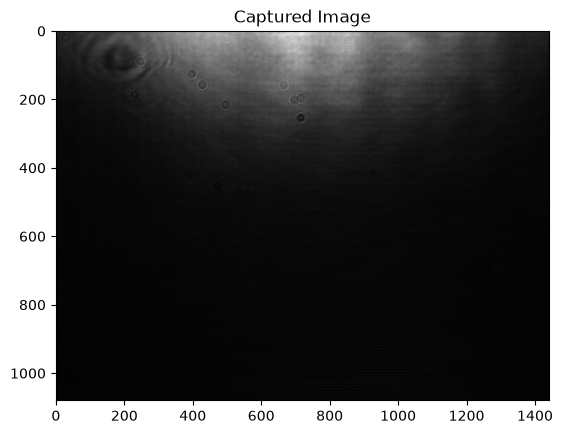

In [8]:
freq, phase, max_val, image, cropped, intensity_profile, x, fitted_y = find_phase(left_value=0)
# print min and max value in image
print(f"Max value in image: {np.max(image)}, Min value in image: {np.min(image)}")
plt.imshow(image, cmap='gray')
plt.title("Captured Image")
plt.show()

Max value in cropped: 54, Min value in cropped: 30


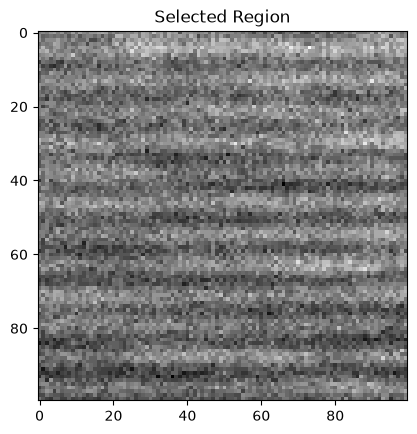

In [9]:
# print min and max value in cropped
print(f"Max value in cropped: {np.max(cropped)}, Min value in cropped: {np.min(cropped)}")
plt.imshow(cropped, cmap='gray')
plt.title("Selected Region")
plt.show()

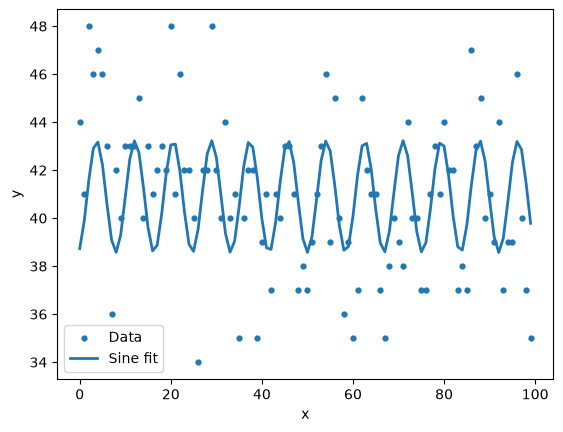

In [10]:
plt.scatter(x, intensity_profile, s=12, label="Data")
plt.plot(x, fitted_y, linewidth=2, label="Sine fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [11]:
# left_value_lift generate a list of left values from 0 to 255 in increments of 25
left_value_list = list(range(0, 256, 1))

left_value_phase_dict = {}

for left_value in left_value_list:
    freq, phase, max_val, image, cropped, intensity_profile, x, fitted_y = find_phase(left_value=left_value)
    # divide phase by pi
    phase = phase / np.pi
    left_value_phase_dict[left_value] = (freq, phase, max_val)
    print(f"Left value: {left_value}, Frequency: {freq}, Phase: {phase}, Max Value: {max_val}")

# plot the phase vs left value
left_values = list(left_value_phase_dict.keys())
phases = [left_value_phase_dict[left_value][1] for left_value in left_values]

Left value: 0, Frequency: 0.12010858074018901, Phase: 0.9751630686215693, Max Value: 494
Left value: 1, Frequency: 0.12005718481241927, Phase: 0.9688815728366751, Max Value: 492
Left value: 2, Frequency: 0.11992532205174235, Phase: -0.9619650378552693, Max Value: 501
Left value: 3, Frequency: 0.12004741919732331, Phase: -0.9667258363367212, Max Value: 500
Left value: 4, Frequency: 0.12020824499291623, Phase: -0.9907764899731213, Max Value: 484
Left value: 5, Frequency: 0.1202716824577961, Phase: -0.9963360393182807, Max Value: 492
Left value: 6, Frequency: 0.12008402134026547, Phase: -0.9850392184577241, Max Value: 491
Left value: 7, Frequency: 0.12023527861647061, Phase: -0.9762542874361964, Max Value: 491
Left value: 8, Frequency: 0.12010302448190598, Phase: -0.9404319714486981, Max Value: 498
Left value: 9, Frequency: 0.12043239940301498, Phase: -0.9556354799317344, Max Value: 496
Left value: 10, Frequency: 0.1202770390418867, Phase: -0.9531122024039592, Max Value: 504
Left value: 1

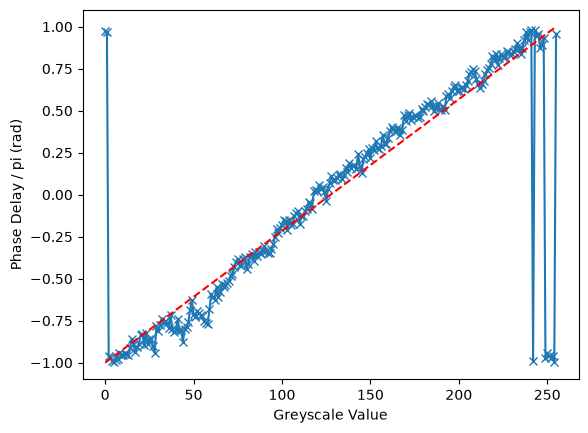

In [17]:
plt.plot(left_values, phases, 'x-')
# plot a line from (0,-1.00) to (255,1.00)
plt.plot([0, 255], [-1.00, 1.00], 'r--')
plt.xlabel("Greyscale Value")
plt.ylabel("Phase Delay / pi (rad)")
plt.show()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

Text(0, 0.5, 'Phase Delay / pi (rad)')

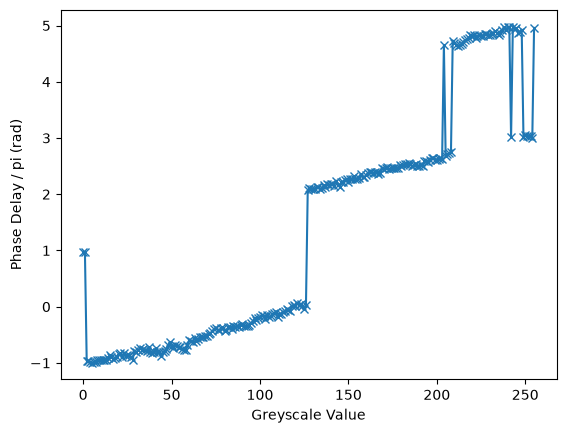

In [18]:
# for all greyscale values greater than 115 add +2 to the phase
adjusted_phases = []
print(left_value_list)
for left_value in left_value_list:
    freq, phase, max_val = left_value_phase_dict[left_value]
    if left_value == 126:
        phase += 0.0
    elif left_value == 204:
        phase += 4.0
    elif left_value > 208:
        phase += 4.0
    elif left_value > 125:
        phase += 2.0
    

    adjusted_phases.append(phase)

    
plt.plot(left_values, adjusted_phases, 'x-')
plt.xlabel("Greyscale Value")
plt.ylabel("Phase Delay / pi (rad)")


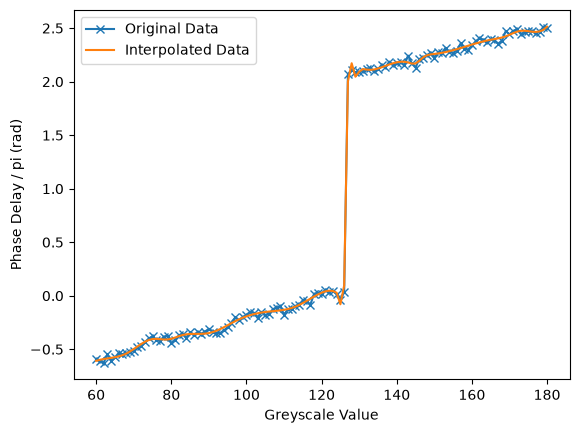

In [19]:
cut_start = 60
cut_end = 180

# cut between values
cut_left_values = left_values[cut_start:cut_end+1]
cut_adjusted_phases = adjusted_phases[cut_start:cut_end+1]

# do spline fit to make interpolation
greyscale_to_phase = scipy.interpolate.UnivariateSpline(cut_left_values, cut_adjusted_phases, s=0.08)
# plot it over the original data
plt.plot(cut_left_values, cut_adjusted_phases, 'x-', label='Original Data')
plt.plot(np.arange(cut_start, cut_end+1), greyscale_to_phase(np.arange(cut_start, cut_end+1)), '-', label='Interpolated Data')
plt.xlabel("Greyscale Value")
plt.ylabel("Phase Delay / pi (rad)")
plt.legend()
plt.show()

In [20]:
# for each greyscale value from 0 to 255, find the corresponding phase using the spline interpolation
greyscale_values = np.arange(cut_start, cut_end+1)  
phase_values = greyscale_to_phase(greyscale_values)
# check it is strictly increasing
is_increasing = all(phase_values[i] < phase_values[i+1] for i in range(len(phase_values)-1))
print(is_increasing)

False


In [21]:
# now read the 19x12_8bit_linearVoltage.lut file into a dictionary with greyscale value as key and voltage as value
lut_greyscale_to_voltage_list = np.loadtxt(lut_path, skiprows=1, usecols=(0, 1))
lut_greyscale_to_voltage = dict(zip(lut_greyscale_to_voltage_list[:, 0], lut_greyscale_to_voltage_list[:, 1]))

# now use this dictionary to plot phase delay against voltage
voltage_values = [lut_greyscale_to_voltage[greyscale] for greyscale in greyscale_values]

phase_to_voltage = scipy.interpolate.UnivariateSpline(phase_values, voltage_values, s=0.0)
# plot it with phase on x-axis and voltage on y-axis
plt.plot(phase_values, voltage_values, 'x-', label='Original Data')
plt.xlabel("Phase Delay / pi (rad)")
plt.ylabel("Voltage (V)")
plt.title("Phase to Voltage Mapping")
plt.show()

ValueError: x must be strictly increasing if s = 0

[1444, 1450, 1455, 1461, 1466, 1472, 1478, 1484, 1490, 1496, 1502, 1508, 1514, 1520, 1525, 1531, 1536, 1541, 1546, 1551, 1556, 1560, 1565, 1569, 1573, 1577, 1581, 1585, 1589, 1593, 1596, 1600, 1603, 1607, 1611, 1614, 1618, 1621, 1625, 1628, 1632, 1635, 1639, 1642, 1646, 1649, 1653, 1657, 1660, 1664, 1668, 1672, 1676, 1680, 1685, 1689, 1694, 1699, 1703, 1708, 1714, 1719, 1725, 1730, 1736, 1741, 1747, 1753, 1759, 1765, 1770, 1776, 1782, 1787, 1793, 1798, 1804, 1809, 1814, 1819, 1824, 1829, 1834, 1839, 1844, 1848, 1853, 1858, 1862, 1867, 1871, 1875, 1880, 1884, 1888, 1892, 1896, 1900, 1904, 1908, 1912, 1916, 1920, 1924, 1928, 1931, 1935, 1939, 1943, 1946, 1950, 1953, 1957, 1961, 1964, 1968, 1971, 1975, 1978, 1982, 1985, 1988, 1992, 1995, 1999, 2002, 2005, 2009, 2012, 2015, 2018, 2022, 2025, 2028, 2032, 2035, 2038, 2041, 2044, 2048, 2051, 2054, 2057, 2060, 2063, 2066, 2070, 2073, 2076, 2079, 2082, 2085, 2088, 2091, 2094, 2097, 2100, 2103, 2107, 2110, 2113, 2116, 2119, 2122, 2125, 2128, 213

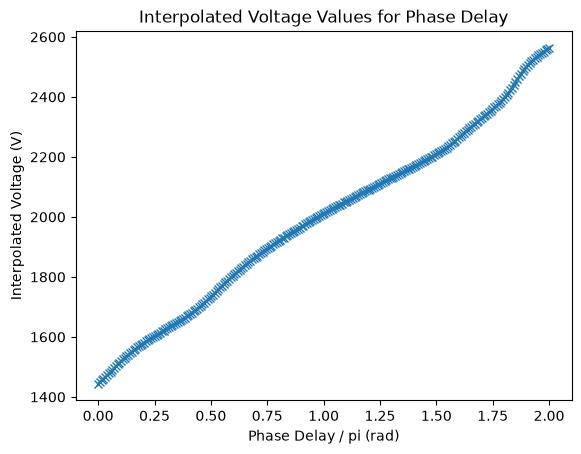

In [ ]:
# now i want an 8bit interpolation of voltages with phase delay ranging from 0 to 2.0 rad
interpolated_voltages = []
for phase in np.linspace(0, 2.0, 256):
    voltage = phase_to_voltage(phase)
    # round voltage to nearest integer
    voltage = int(np.round(voltage))
    interpolated_voltages.append(voltage)

print(interpolated_voltages)


# plot them
plt.plot(np.linspace(0, 2.0, 256), interpolated_voltages, 'x-')
plt.xlabel("Phase Delay / pi (rad)")
plt.ylabel("Interpolated Voltage (V)")
plt.title("Interpolated Voltage Values for Phase Delay")
plt.show()